In [1]:
"""Smoke-test for the Rossmann store sales forecasting pipeline.

Generates a small synthetic dataset with a strong, easy-to-fit weekly pattern,
runs the full feature-engineering → nested CV pipeline, prints test-set metrics,
and plots real vs predicted sales for the last outer fold.

Usage: conda run -n rossmann python test_pipeline.py
"""

import os
import logging
import warnings

import optuna
import numpy as np
import pandas as pd
import xgboost as xgb
import matplotlib.pyplot as plt
import src.constants as C

from matplotlib import cm
from src import features
from src.preprocessing import drop_null_targets
from src.engine.cv import TimeSeriesCV
from src.engine.metrics import compute_metrics
from src.engine import utils, hypertuning

os.makedirs(C.LOG_DIR, exist_ok=True)
logging.basicConfig(level=logging.INFO, 
                    filename=os.path.join(C.LOG_DIR, "test_pipeline.log"),
                    format="%(levelname)s  %(message)s")
optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings("ignore")

logger = logging.getLogger(__name__)




c:\Users\m_kal\Downloads\rossmann_store_sales\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Synthetic Data

Strong deterministic weekly + trend signal so the model can overfit easily and produce low errors.

In [3]:

cv_config = {
    "n_outer_splits":   C.N_OUTER_SPLITS,
    "n_inner_splits":   C.N_INNER_SPLITS,
    "forecast_horizon": 10, #C.FORECAST_HORIZON,
    "inner_train_size": 1000, #C.INNER_TRAIN_SIZE,
}

cv_config["outer_train_size"] = (cv_config["n_inner_splits"] + 1) * cv_config["forecast_horizon"] + cv_config["inner_train_size"]


study_config = {
    "storage_url":           C.STORAGE_URL,
    "n_trials":              C.NUM_TRIALS,
    "n_startup_trials":      C.NUM_STARTUP_TRIALS,
    "n_jobs":                C.NUM_JOBS,
    "seed":                  C.SEED,
    "xgb_constants":         C.XGB_CONSTANTS,
    "early_stopping_rounds": C.EARLY_STOPPING_ROUNDS,
    "num_boost_rounds":      C.NUM_BOOST_ROUNDS,
    "monitor_periods":       C.MONITOR_PERIODS,
    "hyperparameters":       C.HYPERPARAMETERS,
    "log_dir":               C.LOG_DIR,
}


In [ ]:
""" 
# Preprocessing steps:
# 1. Overwrite zero sales for Sundays (closed) with interpolated values based on adjacent open days, 
#    to allow feature creation for those days (e.g. lags, rolls, diffs, forecast horizon)
# 2. First-order differencing on the Sales column to make the series more stationary
# 3. Create features and targets for the whole dataset
# 4. Drop rows with null targets (i.e. those that don't have enough history
#    to create all requested lags, rolls, diffs, and/or forecast horizon)

df_processed = df.copy()
df_processed['Sales'] = (
    utils.overwrite_closed_sales(df_processed['Sales'], mode='interpolate')
    .groupby(level='Store')
    .diff()
)
X = make_features(df_processed, lags, rolling_windows, diffs)
y = make_targets(df_processed['Sales'], FORECAST_HORIZON)
X, y = drop_null_targets(X, y)

cv = TimeSeriesCV(n_splits=cv_config["n_outer_splits"],
                  horizon=cv_config["forecast_horizon"],
                  train_size=cv_config["outer_train_size"])

for fold, (train_ix, test_ix) in enumerate(cv.split(X, y), start=1):
    logger.info(f"Outer fold {fold}/{cv_config['n_outer_splits']} starting...")

    study_name = f"fold_{fold}"
    X_train, y_train = X.iloc[train_ix], y.iloc[train_ix]
    X_test, y_test = X.iloc[test_ix], y.iloc[test_ix]
    
    # Run Optuna hyperparameter tuning with nested CV in the inner loop
    logger.info(f"Running hyperparameter tuning ({study_config['n_trials']} trials)...")
    hypertuning.optimize(study_name, X_train, y_train, {**cv_config, **study_config})

    # Retrain final model on the entire outer fold training set with the best hyperparameters
    logger.info(f"Retraining model with the best hyperparameters...")
    study = optuna.load_study(study_name=study_name, storage=study_config["storage_url"])
    booster = hypertuning.refit(X_train, y_train, study.best_trial, study_config)
    
    logger.info(f"Evaluating final model on outer fold {fold} test set...")
    preds = utils.predict(booster, X_test)

    # Inverse first-order differencing to get predictions back on the original scale
    origin_index = preds.index.droplevel('Forecast Date')
    anchors = (utils.overwrite_closed_sales(df['Sales'], mode='interpolate')
               .loc[origin_index]
               .set_axis(preds.index))
    preds = anchors + preds.groupby(level=['Date', 'Store']).cumsum()
    
    # Log metrics and artifacts
    actuals = utils.retrieve_sales(df['Sales'], preds.index)
    metrics = compute_metrics(actuals.values, preds.values)
    logger.info(f"Test set metrics for fold {fold}: {metrics}")
    
    booster_file = os.path.join(study_config["log_dir"], study_name, "model.ubj")
    preds_file = os.path.join(study_config["log_dir"], study_name, "predictions.csv")
    booster.save_model(booster_file)
    preds.to_csv(preds_file)

    break
"""

' \n# Preprocessing steps:\n# 1. Overwrite zero sales for Sundays (closed) with interpolated values based on adjacent open days, \n#    to allow feature creation for those days (e.g. lags, rolls, diffs, forecast horizon)\n# 2. First-order differencing on the Sales column to make the series more stationary\n# 3. Create features and targets for the whole dataset\n# 4. Drop rows with null targets (i.e. those that don\'t have enough history\n#    to create all requested lags, rolls, diffs, and/or forecast horizon)\n\ndf_processed = df.copy()\ndf_processed[\'Sales\'] = (\n    utils.overwrite_closed_sales(df_processed[\'Sales\'], mode=\'interpolate\')\n    .groupby(level=\'Store\')\n    .diff()\n)\nX = make_features(df_processed, lags, rolling_windows, diffs)\ny = make_targets(df_processed[\'Sales\'], FORECAST_HORIZON)\nX, y = drop_null_targets(X, y)\n\ncv = TimeSeriesCV(n_splits=cv_config["n_outer_splits"],\n                  horizon=cv_config["forecast_horizon"],\n                  train_s

In [4]:
""" Read the Rossmann store sales dataset and preprocess it for modeling. """
sales = pd.read_csv(r'C:\Users\m_kal\Downloads\datasets\rossmann-store-sales\train.csv')
stores = pd.read_csv(r'C:\Users\m_kal\Downloads\datasets\rossmann-store-sales\store.csv')

stores_to_use = [1, 2, 3, 4, 5, 6]
stores = stores[stores['Store'].isin(stores_to_use)]

stores['CompetitionStartDate'] = pd.to_datetime({
    'year': stores['CompetitionOpenSinceYear'],
    'month': stores['CompetitionOpenSinceMonth'],
    'day': 1
    }, errors='coerce')
stores.drop(columns=['CompetitionOpenSinceYear', 'CompetitionOpenSinceMonth'], inplace=True)

df = sales.merge(stores, on='Store', how='inner')
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values(by=['Store', 'Date']) # Sort by Store and Date to ensure chronological order for feature engineering 

no_state_holiday = df['StateHoliday'].isin(['0', 0]) | df['StateHoliday'].isna()
df.loc[no_state_holiday, 'StateHoliday'] = 'NoHoliday'
df['isStateHoliday'] = df['StateHoliday'] != 'NoHoliday'
df['isSchoolHoliday'] = df['SchoolHoliday'].astype(bool)

df['Sales'] = df['Sales'].apply(np.log1p)  # We also apply log1p transformation to stabilize variance and make the distribution more normal.


In [ ]:
import xgboost as xgb
import pandas as pd
from src.engine.hypertuning import _objective
from optuna.trial import FixedTrial
from src.engine.target_transformer import TargetTransformer

FORECAST_HORIZON = 1
lags = [pd.DateOffset(days=i) for i in range(FORECAST_HORIZON * 5)] # lag 0 is the current value, lag 1 is the previous day, etc.
diffs = [pd.DateOffset(days=i) for i in [3, 5, 7, 14, 30]]
windows = ['7D', '14D', '30D', '60D']
horizon = pd.DateOffset(days=FORECAST_HORIZON) # We use this to shift the features by the forecast
                                                   # horizon to align them with the target variable.


# Interpolate sales for closed days to create anchors for inverting the differencing and log transformation on the predictions, so that we can get them back on the original scale for evaluation and plotting.
is_closed = df['Date'].dt.day_name() == 'Sunday'
df_nc = df.copy()
df_nc.loc[is_closed, 'Sales'] = np.nan
df_nc = (df_nc
         .set_index(['Date', 'Store'])
         .sort_index()
         .groupby(level='Store', group_keys=False)
         .apply(lambda x: x.interpolate(method='linear'))
         .reset_index())

X = df_nc.set_index(['Date']).groupby('Store').apply(lambda df: features.compute(df, lags, diffs, windows, horizon))
trf = TargetTransformer(forecast_horizon=pd.DateOffset(days=-FORECAST_HORIZON), anchor_col='lag_days_0')
trf.fit(X)  # Fit the transformer to capture anchors from X so that we can inverse the differencing later when we get the predictions
y = trf.transform(df_nc.set_index(['Store', 'Date'])['Sales'])  # Transform the target variable to compute the forward difference
X = X.loc[y.index]  # Align features with the target variable by dropping any rows in X that don't have a corresponding target value in y.

inner_cv = TimeSeriesCV(n_splits=C.N_INNER_SPLITS,
                        train_size=C.INNER_TRAIN_SIZE,
                        test_size=C.INNER_TEST_SIZE)


# Values must fall within the bounds defined in C.HYPERPARAMETERS
params = {
    'max_depth': 6,
    'learning_rate': 1e-3,
    'subsample': 0.7,        # C.HYPERPARAMETERS bounds: [0.6, 1.0]
    'colsample_bytree': 0.7, # C.HYPERPARAMETERS bounds: [0.6, 1.0]
    'min_child_weight': 1,
    'reg_alpha': 0.1,
    'reg_lambda': 0.1,
    'gamma': 0.1,
}


mock_trial = FixedTrial(params)
obj_fcn = lambda trial: _objective(trial, X, y, inner_cv,
                                study_name='stuff',
                                study_config=study_config)

obj_fcn(mock_trial)


[0]	train-rmse:1.92096+0.08722	test-rmse:1.54251+1.33337
[100]	train-rmse:1.74783+0.07930	test-rmse:1.41339+1.20894
[200]	train-rmse:1.59062+0.07186	test-rmse:1.29729+1.09599
[300]	train-rmse:1.44999+0.06529	test-rmse:1.19397+0.99497
[400]	train-rmse:1.32256+0.05934	test-rmse:1.10007+0.90372
[500]	train-rmse:1.20846+0.05419	test-rmse:1.01653+0.82192
[600]	train-rmse:1.10370+0.04929	test-rmse:0.94015+0.74624
[700]	train-rmse:1.00950+0.04503	test-rmse:0.87129+0.67831
[800]	train-rmse:0.92266+0.04130	test-rmse:0.80805+0.61545
[900]	train-rmse:0.84436+0.03764	test-rmse:0.75122+0.55842
[1000]	train-rmse:0.77368+0.03444	test-rmse:0.70007+0.50735
[1100]	train-rmse:0.70980+0.03162	test-rmse:0.65392+0.46080
[1200]	train-rmse:0.65218+0.02914	test-rmse:0.61240+0.41918
[1300]	train-rmse:0.59910+0.02677	test-rmse:0.57409+0.38034
[1400]	train-rmse:0.55176+0.02474	test-rmse:0.54033+0.34625
[1500]	train-rmse:0.50874+0.02289	test-rmse:0.50950+0.31511
[1600]	train-rmse:0.47061+0.02122	test-rmse:0.48219+

np.float64(0.22094452441225876)

In [16]:
booster = hypertuning.refit(X, y, mock_trial, study_config)
test_dmatrix = xgb.DMatrix(X, enable_categorical=True)
preds_log_diff = pd.Series(data=booster.predict(test_dmatrix),
                           index=X.index)
preds = trf.inverse_transform(preds_log_diff)  # Inverse transform to get predictions back on the original scale

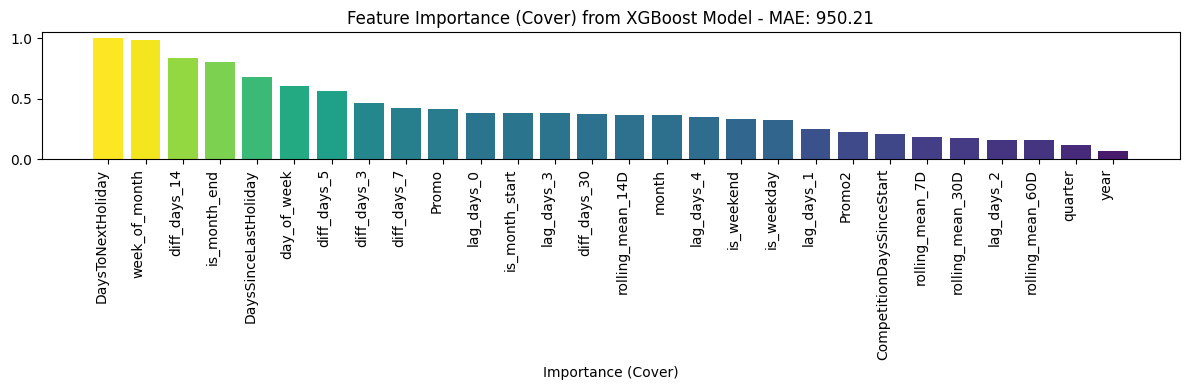

In [18]:
# Extract feature importance from the booster and plot it
importance = booster.get_score(importance_type='cover')
importance_df = pd.DataFrame({
    'feature': list(importance.keys()),
    'importance': list(importance.values())
}).sort_values(by='importance', ascending=False)

importance_df['importance'] = importance_df['importance'] / importance_df['importance'].max()  # Normalize to sum to 1

results = pd.DataFrame({
    'actuals': df.set_index(['Store', 'Date'])['Sales'].apply(np.expm1),  # Inverse of log1p applied to the targets during training
    'predictions': preds
}).dropna().sort_index()

from sklearn.metrics import  mean_absolute_error
mae = mean_absolute_error(results["actuals"], results["predictions"])

plt.figure(figsize=(12, 4))
plt.bar(importance_df['feature'], importance_df['importance'], color=cm.viridis(importance_df['importance']))
plt.xlabel('Importance (Cover)')
plt.title('Feature Importance (Cover) from XGBoost Model - MAE: {:.2f}'.format(mae))
# rotate x-axis labels for better readability
plt.xticks(rotation=90, ha='right')
plt.tight_layout()

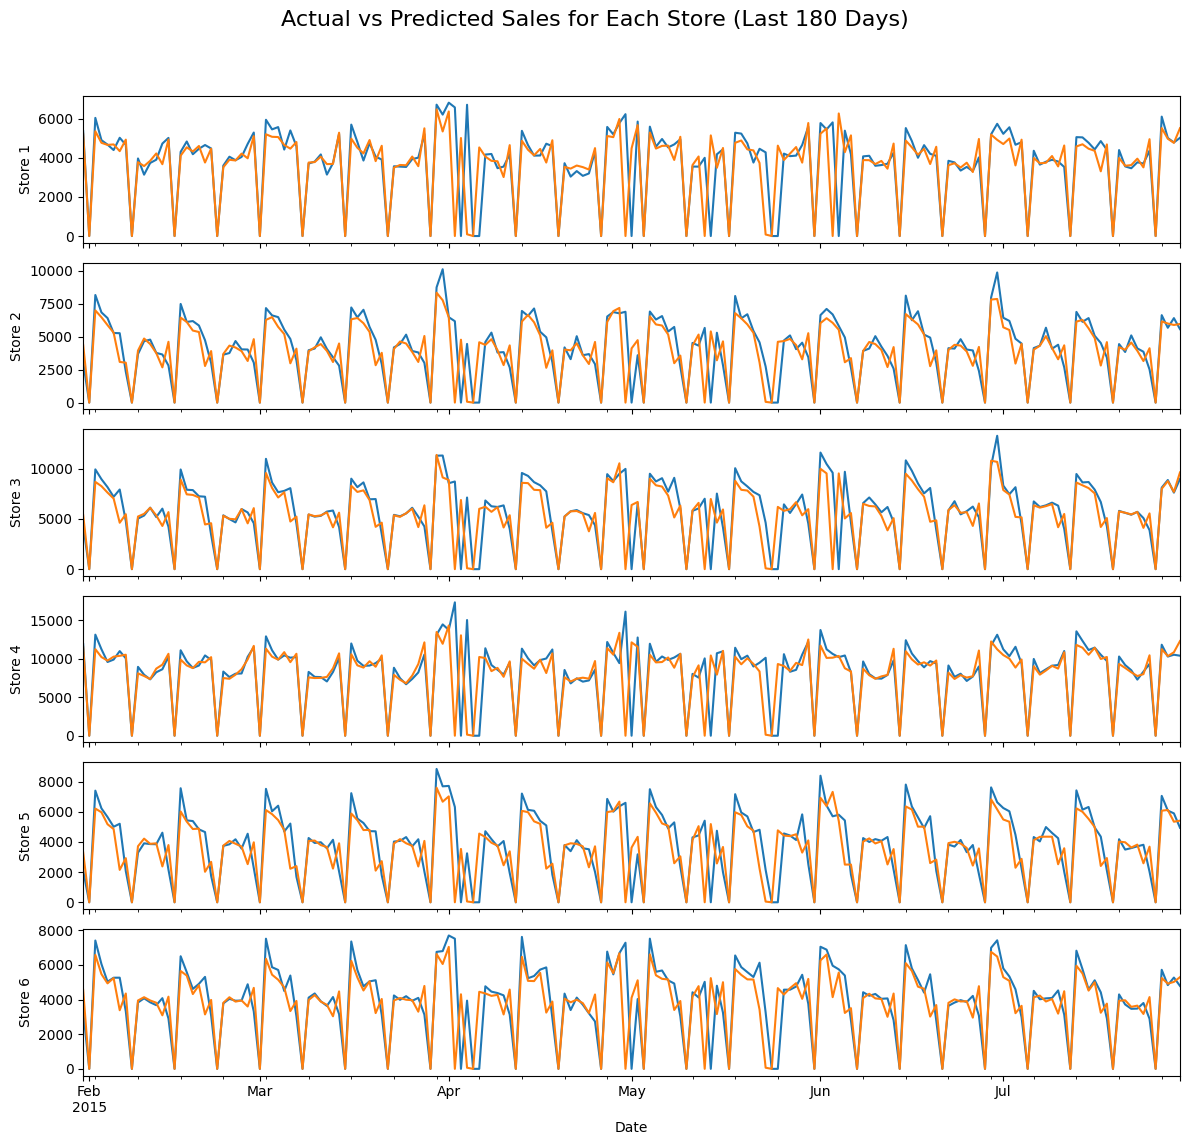

In [20]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

n_days_to_plot = 6*30
max_date = results.index.get_level_values("Date").max()
min_date = results.index.get_level_values("Date").max() - pd.Timedelta(days=n_days_to_plot)
actuals_recent = results.loc[(slice(None), slice(min_date, max_date)), 'actuals']
preds_recent = results.loc[(slice(None), slice(min_date, max_date)), 'predictions']

stores = actuals_recent.index.get_level_values("Store").unique()

fig, ax = plt.subplots(figsize=(12, 2 * len(stores)), nrows=len(stores), sharex=True, sharey=False)

for i, store in enumerate(stores):

    actual_store_sales = actuals_recent.loc[(store, slice(None))]
    predicted_store_sales = preds_recent.loc[(store, slice(None))]
    
    actual_store_sales.plot(label=f"Actual", ax=ax[i])
    predicted_store_sales.plot(label=f"Predicted", ax=ax[i])

    # Add x markers to indicate closed days (Sundays) on the plot
    closed_days = actual_store_sales.index.get_level_values("Date").day_name() == 'Sunday'
    closed_days = actual_store_sales[closed_days].index.get_level_values("Date")
    #for closed_day in closed_days:
    #    ax[i].axvline(x=closed_day, color='red', linestyle='--', alpha=0.5, label='Closed Day' if closed_day == closed_days[0] else "")
    
    #ax[i].legend()
    ax[i].set_ylabel("Store {}".format(store))
    ax[i].set_xlabel("Date")
plt.suptitle("Actual vs Predicted Sales for Each Store (Last {} Days)".format(n_days_to_plot), fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])  # Adjust layout to make room for the suptitle